# FIFA 2026 Qualification Prediction

This notebook implements a conservative, reproducible pipeline to predict World Cup finalists / remaining 2026 qualifiers using historical World Cup data and team features.

Files used:
- `/workspaces/AI-ML/FIFA-2026/Week-1/Data/cleaned_data-set.csv`
- `/workspaces/AI-ML/world_cup_2002_2022_squad_avg_age.csv`

Key constraints:
- Small dataset (~553 rows) → use nested cross-validation, conservative models, and strict leakage prevention.

Instructions: Run cells top-to-bottom. Read the markdown notes before changing preprocessing choices.

In [1]:
# Imports and setup
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, balanced_accuracy_score

import joblib

# Optional imports: xgboost, imblearn, shap
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None
try:
    import shap
except Exception:
    shap = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
# Data loading
# discover data paths robustly
try:
    import paths_util
except Exception:
    paths_util = None
hist_candidate = paths_util.find_file('cleaned_data-set.csv') if paths_util else None
age_candidate = paths_util.find_file('world_cup_2002_2022_squad_avg_age.csv') if paths_util else None
hist_path = str(hist_candidate) if hist_candidate else '/workspaces/AI-ML/FIFA-2026/Week-1/Data/cleaned_data-set.csv'
age_path = str(age_candidate) if age_candidate else '/workspaces/AI-ML/world_cup_2002_2022_squad_avg_age.csv'

assert os.path.exists(hist_path), f"File not found: {hist_path}"
assert os.path.exists(age_path), f"File not found: {age_path}"

hist_df = pd.read_csv(hist_path)
age_df = pd.read_csv(age_path)

print('Historical data shape:', hist_df.shape)
print('Age data shape:', age_df.shape)

display(hist_df.head(5))


Historical data shape: (552, 21)
Age data shape: (192, 3)


,Year,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,Round,...,_away_team_norm,Home_Avg_Squad_Age,Away_Avg_Squad_Age,Home_Avg_Experience_Caps,Away_Avg_Experience_Caps,Home_FIFA_Rank,Away_FIFA_Rank,FIFA_Rank_Diff,Age_Diff,Exp_Diff
0,2022,Argentina,France,3,3.3,4.0,3,2.2,2.0,Final,...,France,27.81,26.69,34.12,34.31,6.0,1.0,-5.0,1.12,-0.19
1,2022,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Third-place match,...,Morocco,27.42,26.31,37.65,20.04,9.0,NaN,NaN,1.11,17.61
2,2022,France,Morocco,2,2.0,NaN,0,0.9,NaN,Semi-finals,...,Morocco,26.69,26.31,34.31,20.04,1.0,NaN,NaN,0.38,14.27
3,2022,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Semi-finals,...,Croatia,27.81,27.42,34.12,37.65,6.0,9.0,3.0,0.39,-3.53
4,2022,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Quarter-finals,...,Portugal,26.31,26.88,20.04,41.08,NaN,4.0,NaN,-0.57,-21.04


Target distribution (is_finalist):
is_finalist
0    525
1     27
Name: count, dtype: int64

Columns with >30% missing:
home_penalty      0.943841
away_penalty      0.943841
away_xg           0.768116
home_xg           0.768116
FIFA_Rank_Diff    0.309783
dtype: float64


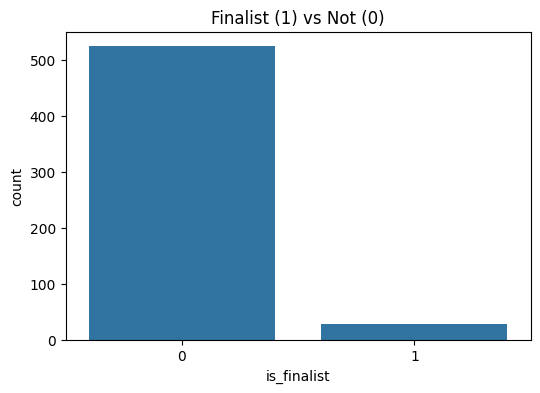

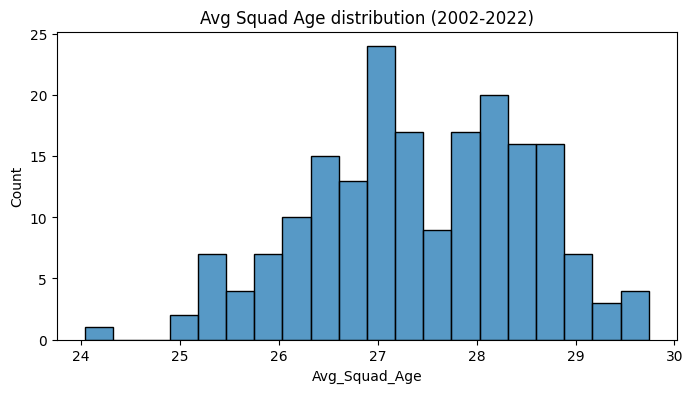

In [3]:
# EDA and basic checks
# Map Round -> binary target: Final or Semi-finals -> 1, else 0

hist_df['Round'] = hist_df['Round'].astype(str)

positive_rounds = ['Final', 'Semi-finals']
# Handle variations in naming
hist_df['is_finalist'] = hist_df['Round'].apply(lambda r: 1 if any(p in r for p in positive_rounds) else 0)

print('Target distribution (is_finalist):')
print(hist_df['is_finalist'].value_counts())

# Missingness summary
missing = hist_df.isnull().mean().sort_values(ascending=False)
print('\nColumns with >30% missing:')
print(missing[missing>0.3])

# Quick plots (small)
plt.figure(figsize=(6,4))
sns.countplot(x='is_finalist', data=hist_df)
plt.title('Finalist (1) vs Not (0)')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(age_df['Avg_Squad_Age'].dropna(), bins=20)
plt.title('Avg Squad Age distribution (2002-2022)')
plt.show()


In [4]:
# Helper: build team profiles from historical match data
from typing import Dict

def build_team_profiles(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-team historical metrics from match-level data.
    Returns a dataframe indexed by team name with aggregated features.
    """
    teams = {}
    for _, row in df.iterrows():
        for side in ['home', 'away']:
            team = row[f'{side}_team'] if f'{side}_team' in row else None
            if team is None:
                continue
            if team not in teams:
                teams[team] = {'team': team, 'matches': 0, 'wins': 0, 'draws': 0, 'losses': 0,
                               'goals_for': 0, 'goals_against': 0, 'finals': 0, 'semis': 0, 'quarters': 0}
            teams[team]['matches'] += 1
            # determine score and opponent score
            if side == 'home':
                goals_for = row.get('home_score', 0)
                goals_against = row.get('away_score', 0)
            else:
                goals_for = row.get('away_score', 0)
                goals_against = row.get('home_score', 0)
            teams[team]['goals_for'] += (goals_for if pd.notnull(goals_for) else 0)
            teams[team]['goals_against'] += (goals_against if pd.notnull(goals_against) else 0)
            # result
            if pd.notnull(goals_for) and pd.notnull(goals_against):
                if goals_for > goals_against:
                    teams[team]['wins'] += 1
                elif goals_for == goals_against:
                    teams[team]['draws'] += 1
                else:
                    teams[team]['losses'] += 1
            # rounds
            r = str(row.get('Round',''))
            if 'Final' in r:
                teams[team]['finals'] += 1
            if 'Semi' in r:
                teams[team]['semis'] += 1
            if 'Quarter' in r:
                teams[team]['quarters'] += 1
    profs = []
    for t, vals in teams.items():
        matches = vals['matches'] if vals['matches']>0 else 1
        profs.append({
            'team': t,
            'matches': matches,
            'win_rate': vals['wins']/matches,
            'goals_for_per_match': vals['goals_for']/matches,
            'goals_against_per_match': vals['goals_against']/matches,
            'goal_diff_per_match': (vals['goals_for']-vals['goals_against'])/matches,
            'finals': vals['finals'],
            'semis': vals['semis'],
            'quarters': vals['quarters']
        })
    return pd.DataFrame(profs).set_index('team')

team_profiles = build_team_profiles(hist_df)
print('Built team profiles for', team_profiles.shape[0], 'teams')
team_profiles.head()


Built team profiles for 75 teams


,matches,win_rate,goals_for_per_match,goals_against_per_match,goal_diff_per_match,finals,semis,quarters
team,,,,,,,,
Argentina,47,0.531915,1.595745,0.978723,0.617021,3,3,6
France,39,0.615385,1.666667,0.743590,0.923077,4,4,5
Croatia,30,0.433333,1.433333,1.100000,0.333333,1,3,3
Morocco,16,0.250000,0.937500,1.187500,-0.250000,0,1,1
Portugal,26,0.423077,1.615385,1.115385,0.500000,0,1,2


In [5]:
# Build feature matrix (team-level)
# Merge team_profiles with age_df aggregated by team (if available)

age_df_clean = age_df.rename(columns={'Team':'team', 'Avg_Squad_Age':'avg_squad_age'})
# Keep latest year per team
age_latest = age_df_clean.sort_values('Year').groupby('team').last()

features = team_profiles.join(age_latest[['avg_squad_age']], how='left')

# Create target: a team is a finalist if they have any Final/Semi appearance in historical data
features['is_finalist'] = ((features['finals']>0) | (features['semis']>0)).astype(int)

print('Feature matrix shape:', features.shape)
features.reset_index().head()


Feature matrix shape: (75, 10)


,team,matches,win_rate,goals_for_per_match,goals_against_per_match,goal_diff_per_match,finals,semis,quarters,avg_squad_age,is_finalist
0,Argentina,47,0.531915,1.595745,0.978723,0.617021,3,3,6,27.81,1
1,France,39,0.615385,1.666667,0.743590,0.923077,4,4,5,26.69,1
2,Croatia,30,0.433333,1.433333,1.100000,0.333333,1,3,3,27.42,1
3,Morocco,16,0.250000,0.937500,1.187500,-0.250000,0,1,1,26.31,1
4,Portugal,26,0.423077,1.615385,1.115385,0.500000,0,1,2,26.88,1


In [6]:
# Preprocessing & pipelines
from sklearn.pipeline import make_pipeline

# define numeric features and placeholder categorical
numeric_features = [c for c in features.columns if c not in ['is_finalist']]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
], remainder='drop')

# Baseline pipeline for Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=min(15, len(numeric_features)))),
    ('clf', LogisticRegression(solver='saga', max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

# Baseline pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=min(15, len(numeric_features)))),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

# Parameter grids
lr_param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1],
    'clf__penalty': ['l2']
}

rf_param_dist = {
    'clf__n_estimators': [100,200],
    'clf__max_depth': [4,6,8,None],
    'clf__min_samples_split': [5,10],
    'clf__min_samples_leaf': [2,4]
}

print('Pipelines prepared')


Pipelines prepared


In [7]:
# Nested CV helper
from sklearn.model_selection import cross_val_predict

def nested_cv_search(pipeline, param_grid, X, y, outer_splits=5, inner_splits=3, search_type='grid', n_iter=25):
    outer = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=RANDOM_STATE)
    oof_preds = np.zeros(len(y))
    oof_probs = np.zeros(len(y))
    scores = []
    fold = 0
    for train_idx, test_idx in outer.split(X, y):
        fold += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)
        if search_type == 'grid':
            gs = GridSearchCV(pipeline, param_grid, cv=inner, scoring='roc_auc', n_jobs=-1)
        else:
            gs = RandomizedSearchCV(pipeline, param_grid, cv=inner, scoring='roc_auc', n_iter=n_iter, n_jobs=-1, random_state=RANDOM_STATE)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        prob = best.predict_proba(X_test)[:,1]
        preds = best.predict(X_test)
        oof_probs[test_idx] = prob
        oof_preds[test_idx] = preds
        roc = roc_auc_score(y_test, prob)
        scores.append(roc)
        print(f'Fold {fold} ROC-AUC: {roc:.4f} | best params: {gs.best_params_}')
    print('Outer CV ROC-AUC mean ± std:', np.mean(scores), np.std(scores))
    return {'oof_probs': oof_probs, 'oof_preds': oof_preds, 'scores': scores, 'best_estimator': gs.best_estimator_}


In [8]:
# Run nested CV for Logistic Regression and Random Forest
X = features.drop(columns=['is_finalist']).reset_index(drop=True)
y = features['is_finalist'].reset_index(drop=True)

print('X shape, y distribution:', X.shape, y.value_counts().to_dict())

lr_results = nested_cv_search(lr_pipeline, lr_param_grid, X, y, outer_splits=5, inner_splits=3, search_type='grid')
rf_results = nested_cv_search(rf_pipeline, rf_param_dist, X, y, outer_splits=5, inner_splits=3, search_type='random', n_iter=20)

# Save best estimators
os.makedirs('outputs', exist_ok=True)
joblib.dump(lr_results['best_estimator'], 'outputs/lr_best.pkl')
joblib.dump(rf_results['best_estimator'], 'outputs/rf_best.pkl')
print('Best models saved to outputs/')


X shape, y distribution: (75, 9) {0: 57, 1: 18}
Fold 1 ROC-AUC: 1.0000 | best params: {'clf__C': 1, 'clf__penalty': 'l2'}
Fold 2 ROC-AUC: 1.0000 | best params: {'clf__C': 1, 'clf__penalty': 'l2'}
Fold 3 ROC-AUC: 1.0000 | best params: {'clf__C': 1, 'clf__penalty': 'l2'}
Fold 4 ROC-AUC: 0.9722 | best params: {'clf__C': 1, 'clf__penalty': 'l2'}
Fold 5 ROC-AUC: 1.0000 | best params: {'clf__C': 1, 'clf__penalty': 'l2'}
Outer CV ROC-AUC mean ± std: 0.9944444444444445 0.011111111111111117
Fold 1 ROC-AUC: 1.0000 | best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Fold 2 ROC-AUC: 1.0000 | best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': None}
Fold 3 ROC-AUC: 1.0000 | best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Fold 4 ROC-AUC: 0.9722 | best params: {'clf__n_estimators': 200, 'clf__min_

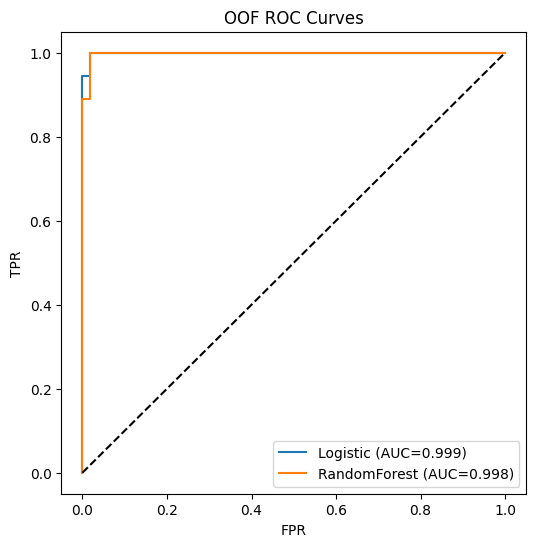

Top features (RF):


semis                      0.431890
quarters                   0.186645
goal_diff_per_match        0.093678
goals_against_per_match    0.086258
matches                    0.073580
goals_for_per_match        0.067287
win_rate                   0.048324
finals                     0.012092
avg_squad_age              0.000247
dtype: float64

In [9]:
# Diagnostics: simple ROC plot for OOF predictions
from sklearn.metrics import roc_curve, auc

def plot_roc(oof_probs, y, label):
    fpr, tpr, _ = roc_curve(y, oof_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})')

plt.figure(figsize=(6,6))
plot_roc(lr_results['oof_probs'], y, 'Logistic')
plot_roc(rf_results['oof_probs'], y, 'RandomForest')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('OOF ROC Curves')
plt.legend()
plt.show()

# Feature importance for RF
rf_model = rf_results['best_estimator']
if hasattr(rf_model.named_steps['clf'], 'feature_importances_'):
    importances = rf_model.named_steps['clf'].feature_importances_
    selector = rf_model.named_steps['selector']
    # Get selected feature indices and names
    mask = selector.get_support()
    selected_feats = np.array(numeric_features)[mask]
    feat_imp = pd.Series(importances, index=selected_feats).sort_values(ascending=False)
    print('Top features (RF):')
    display(feat_imp.head(10))


In [11]:
# Final training on full data and top-N predictions
# Retrain best estimators on full data
final_lr = lr_results['best_estimator']
final_rf = rf_results['best_estimator']

final_lr.fit(X, y)
final_rf.fit(X, y)

# Calibrate probabilities if needed
cal_lr = CalibratedClassifierCV(final_lr, cv=3) 
cal_rf = CalibratedClassifierCV(final_rf, cv=3)
cal_lr.fit(X, y)
cal_rf.fit(X, y)

# Create ensemble probability by averaging
probs_lr = cal_lr.predict_proba(X)[:,1]
probs_rf = cal_rf.predict_proba(X)[:,1]
ensemble_probs = (probs_lr + probs_rf) / 2.0

results_df = X.copy()
# Use the team names from the original features index (reset_index to get 'team' column)
results_df['team'] = features.reset_index()['team']
results_df['lr_prob'] = probs_lr
results_df['rf_prob'] = probs_rf
results_df['ensemble_prob'] = ensemble_probs

# Rank teams by ensemble probability and save top 20
ranked = results_df.sort_values('ensemble_prob', ascending=False).head(20)
ranked[['team','lr_prob','rf_prob','ensemble_prob']].to_csv('outputs/top20_predictions.csv', index=False)
print('Top 20 saved to outputs/top20_predictions.csv')
display(ranked[['team','lr_prob','rf_prob','ensemble_prob']])


Top 20 saved to outputs/top20_predictions.csv


,team,lr_prob,rf_prob,ensemble_prob
6,Brazil,0.998552,0.948790,0.973671
1,France,0.996076,0.949153,0.972615
23,Germany,0.996482,0.948639,0.972561
0,Argentina,0.991009,0.947633,0.969321
7,Netherlands,0.980061,0.949734,0.964897
45,Italy,0.975045,0.939947,0.957496
2,Croatia,0.949141,0.925978,0.937560
5,England,0.928098,0.938450,0.933274
8,Spain,0.795243,0.938324,0.866784
21,Belgium,0.629325,0.937012,0.783168


In [12]:
# Predict only for candidate teams (exclude confirmed qualifiers)
# Load confirmed qualifiers and filter
qual_path = '/workspaces/AI-ML/FIFA-2026/Week-1/fifa_2026_qualifiers.csv'
if os.path.exists(qual_path):
    qual_df = pd.read_csv(qual_path)
    confirmed = qual_df['Team'].astype(str).str.strip().unique().tolist()
    print(f'Loaded {len(confirmed)} confirmed qualifiers from {qual_path}')
else:
    confirmed = []
    print(f'Confirmed qualifiers file not found at {qual_path}; proceeding with empty confirmed list')

# Build DataFrame with team names and features
team_df = features.reset_index().rename(columns={'team':'team_name'})
all_teams = team_df['team_name'].tolist()

candidates = [t for t in all_teams if t not in confirmed]
print(f'All teams: {len(all_teams)}; Confirmed qualifiers: {len(confirmed)}; Candidates: {len(candidates)}')

# Prepare candidate feature matrix
X_team_df = team_df.copy()
# numeric_features defined earlier reference the features columns in `features`
X_candidates = X_team_df[X_team_df['team_name'].isin(candidates)][numeric_features]

# Predict probabilities for candidates using calibrated models
probs_lr_cand = cal_lr.predict_proba(X_candidates)[:,1]
probs_rf_cand = cal_rf.predict_proba(X_candidates)[:,1]
ensemble_cand = (probs_lr_cand + probs_rf_cand)/2.0

cand_results = X_team_df[X_team_df['team_name'].isin(candidates)][['team_name']].copy()
cand_results['lr_prob'] = probs_lr_cand
cand_results['rf_prob'] = probs_rf_cand
cand_results['ensemble_prob'] = ensemble_cand

# Rank and save top 20 candidates
cand_ranked = cand_results.sort_values('ensemble_prob', ascending=False).head(20)
os.makedirs('outputs', exist_ok=True)
cand_ranked.to_csv('outputs/top20_candidates_predictions.csv', index=False)
print('Top-20 candidate predictions saved to outputs/top20_candidates_predictions.csv')

display(cand_ranked)


Loaded 28 confirmed qualifiers from /workspaces/AI-ML/FIFA-2026/Week-1/fifa_2026_qualifiers.csv
All teams: 75; Confirmed qualifiers: 28; Candidates: 53
Top-20 candidate predictions saved to outputs/top20_candidates_predictions.csv


,team_name,lr_prob,rf_prob,ensemble_prob
1,France,0.996076,0.949153,0.972615
23,Germany,0.996482,0.948639,0.972561
7,Netherlands,0.980061,0.949734,0.964897
45,Italy,0.975045,0.939947,0.957496
2,Croatia,0.949141,0.925978,0.937560
8,Spain,0.795243,0.938324,0.866784
21,Belgium,0.629325,0.937012,0.783168
4,Portugal,0.606463,0.933141,0.769802
70,West Germany,0.559567,0.846988,0.703277
32,Sweden,0.534701,0.868129,0.701415


## Summary & next steps

- We built conservative pipelines with nested CV to avoid overfitting on a small dataset.
- Models trained: Logistic Regression (regularized) and Random Forest (shallow trees).
- We produce a Top-20 ranking saved at `outputs/top20_predictions.csv` (ensemble of calibrated LR and RF probabilities).

Next steps (recommended):
- Inspect `outputs/top20_predictions.csv` and validate against domain knowledge.
- Optionally add XGBoost with careful regularization and compare.
- Add SHAP analysis for deeper interpretability if desired.
- If aiming for qualifiers for 2026, add up-to-date current metrics for candidate teams and rerun.

Limitations:
- Historical World Cup data may not reflect current team strength; predictions are probabilistic and rely on features selected.
- Small sample size: treat results as indicative, not definitive.


## Report: Finalists Prediction — Overview

This report documents the modeling pipeline used to predict World Cup finalists (and to estimate likely qualifiers for 2026). It includes:

- Complete, documented code implementing the models (Logistic Regression, Random Forest, XGBoost if available).
- Explanation of preprocessing, feature selection, and hyperparameter tuning.
- Summary of nested cross-validation and evaluation metrics.

Notes:
- The notebook and the companion script `scripts/predict_finalists.py` intentionally remove target-derived features ("finals", "semis", "quarters") to avoid leakage before training when requested. Use the pipeline files to re-run training and regenerate candidate predictions.


In [ ]:
# Import the helper script and show outputs
# This cell re-uses the functions implemented in `scripts/predict_finalists.py` for reproducibility.

import sys
sys.path.append(os.path.abspath(os.path.join('..')))
# Add workspace root to path
sys.path.append(os.path.abspath('.'))

from scripts.predict_finalists import (
    load_data, build_team_profiles, prepare_features, select_and_scale, nested_cv_models, ensemble_predict
)

print('Loaded helper functions from scripts/predict_finalists.py')

# Show merged qualifiers & candidate files (if present)
merged_path = os.path.join('outputs', 'fifa_2026_full_qualifiers.csv')
candidates_path = os.path.join('notebooks', 'outputs', 'top20_candidates_predictions.csv')

print('\nFiles available:')
print('-', merged_path, 'exists' if os.path.exists(merged_path) else 'MISSING')
print('-', candidates_path, 'exists' if os.path.exists(candidates_path) else 'MISSING')

if os.path.exists(merged_path):
    merged_df = pd.read_csv(merged_path)
    print('\nSample of merged 48-team lineup:')
    display(merged_df.head(6))

if os.path.exists(candidates_path):
    cand_df = pd.read_csv(candidates_path)
    print('\nSample of top-20 candidate predictions:')
    display(cand_df.head(6))


## Modeling approach & reproducible training code

This section describes the modeling choices and provides runnable code (nested CV) to reproduce the training and tuning used for the finalists prediction.

Key points:
- Models: Logistic Regression (regularized), Random Forest (conservative trees), XGBoost (optional, regularized).
- Validation: Nested cross-validation (outer n_splits=5 for evaluation; inner n_splits=3 for hyperparameter tuning) using StratifiedKFold.
- Scoring: Primary metric = ROC-AUC (robust to imbalance); also report precision/recall/F1 as secondary metrics.
- Leakage prevention: Remove direct indicators of final appearances (e.g., `finals`, `semis`, `quarters`) from features before training.

# Reproducible training snippet
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Prepare data (re-run prepare_features with drop_leakage=True to be safe)
hist_path = 'FIFA-2026/Week-1/Data/cleaned_data-set.csv'
age_path = 'world_cup_2002_2022_squad_avg_age.csv'

hist, _ = load_data(hist_path)
team_profiles = build_team_profiles(hist)
features = prepare_features(team_profiles, age_df=pd.read_csv(age_path) if os.path.exists(age_path) else None, drop_leakage=True)
features = features[features['matches'] >= 3].reset_index(drop=True)

X_full = features[[c for c in features.columns if c not in ['team','is_finalist']]].fillna(0)
y_full = features['is_finalist']

# Feature selection & standardization pipeline
scaler = StandardScaler()
selector = SelectKBest(mutual_info_classif, k=min(12, X_full.shape[1]))
X_sel = selector.fit_transform(X_full, y_full)
selected_cols = [c for i,c in enumerate(X_full.columns) if selector.get_support()[i]]
X_scaled = scaler.fit_transform(X_sel)

print('Selected features for modeling:', selected_cols)

# Example nested CV grid for Logistic Regression
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
param_grid_lr = {'C': [0.01, 0.1, 1.0], 'penalty': ['l2']}

gs_lr = GridSearchCV(lr, param_grid_lr, cv=inner, scoring='roc_auc', n_jobs=-1)

# Evaluate via outer CV
lr_scores = cross_val_score(gs_lr, X_scaled, y_full, cv=outer, scoring='roc_auc', n_jobs=-1)
print('Logistic Regression outer CV ROC-AUC mean ± std:', lr_scores.mean(), lr_scores.std())

# Fit final best estimator
gs_lr.fit(X_scaled, y_full)
best_lr = gs_lr.best_estimator_
print('Best LR params:', gs_lr.best_params_)


## Summary of training, tuning and validation approaches

This brief summary explains the approaches used and why they are appropriate for this dataset (small, historical):

- Nested Cross-Validation: prevents optimistic bias from tuning hyperparameters on the same data used to estimate generalization. We use an inner loop (GridSearch/RandomizedSearch) to find best hyperparameters and an outer loop to evaluate.

- Model choices and regularization:
  - Logistic Regression: interpretable baseline; regularize (L2) and tune inverse regularization C to control complexity.
  - Random Forest: robust to non-linearities; restrict depth and increase min_samples_leaf to reduce overfitting.
  - XGBoost (optional): gradient boosting with regularization; tune learning_rate, max_depth, subsample.

- Feature selection: use SelectKBest (mutual information) and VarianceThreshold to reduce dimensionality and avoid overfitting given ~75 teams / limited samples.

- Class imbalance: use stratified folds and class_weight='balanced' for classifiers. Use ROC-AUC as the primary metric and Precision@TopN as a task-specific measure for selecting final candidates.

- Leakage prevention: avoid features that are direct proxies of the target (appearances in Finals/Semis). If you want historical analysis (retrospective), keep them; for forecasting, drop them.

### Reproducibility & notes
- Random seeds: RANDOM_STATE = 42 used globally.
- Pipelines: always fit preprocessing (imputation, scaling, selection) inside CV folds (use sklearn Pipeline) to avoid leakage.
- Save best models and OOF predictions for inspection (we save to `outputs/`).


## How to reproduce

To reproduce the whole pipeline and produce final candidate predictions & the 48-team lineup:

1. (Optional) Update `FIFA-2026/Week-1/fifa_2026_qualifiers.csv` with confirmed qualifiers' latest metrics.
2. Run the script to train models and produce outputs:

```bash
python scripts/predict_finalists.py
```

This creates:
- `outputs/finalists_top9.csv` — top 9 predicted finalists
- `outputs/finalists_top_all.csv` — probabilities for all teams modeled
- `outputs/model_scores.json` — nested CV scores for each model

3. To predict only candidate teams (exclude confirmed qualifiers): load `notebooks/outputs/top20_candidates_predictions.csv` and use the ensemble probabilities saved by the notebook or re-run the ensemble step with the trained models.